In [1]:
from pathlib import Path
import sys
import warnings
import os
import gc
from copy import deepcopy

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.ops import MLP
import torch.optim as optim
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, StratifiedKFold
from torch.utils.data import Dataset, TensorDataset, DataLoader, Subset
import optuna
import joblib
from optuna.samplers import TPESampler

import random
import math
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import anndata
from anndata import AnnData
import pickle

sys.path.insert(0, "../../")

import scgpt as scg
from scgpt.tokenizer import GeneVocab
from scgpt import logger

warnings.filterwarnings("ignore", category=ResourceWarning)

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    
seed = 13
seed_everything(seed)

/home/harshil.sharma/miniconda3/envs/gene2ephys/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/allen/programs/mindscope/workgroups/auto-model/harshil.sharma/TransformerEphysPrediction/Human/w_types_comparison/../../scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/allen/programs/mindscope/workgroups/auto-model/harshil.sharma/TransformerEphysPrediction/Human/w_types_comparison/../../scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


In [2]:
cell_embeddings_adata = anndata.read_h5ad("../Data Preprocessing/cell_embeddings_adata.h5ad")
combined_ephys_df = pd.read_pickle("../Data Preprocessing/combined_ephys_df.pkl")

models = ["scgpt", "hvg", "ion"]

with open('w_types_results.pkl', 'rb') as f:
    results = pickle.load(f)
shuffled_cell_indices = np.load('w_types_shuffled_cell_indices.npy')
ephys_truth = np.load('w_types_ephys_truth.npy')

ephys_feature_names = [col for col in combined_ephys_df.columns if col != "SpecimenID"]

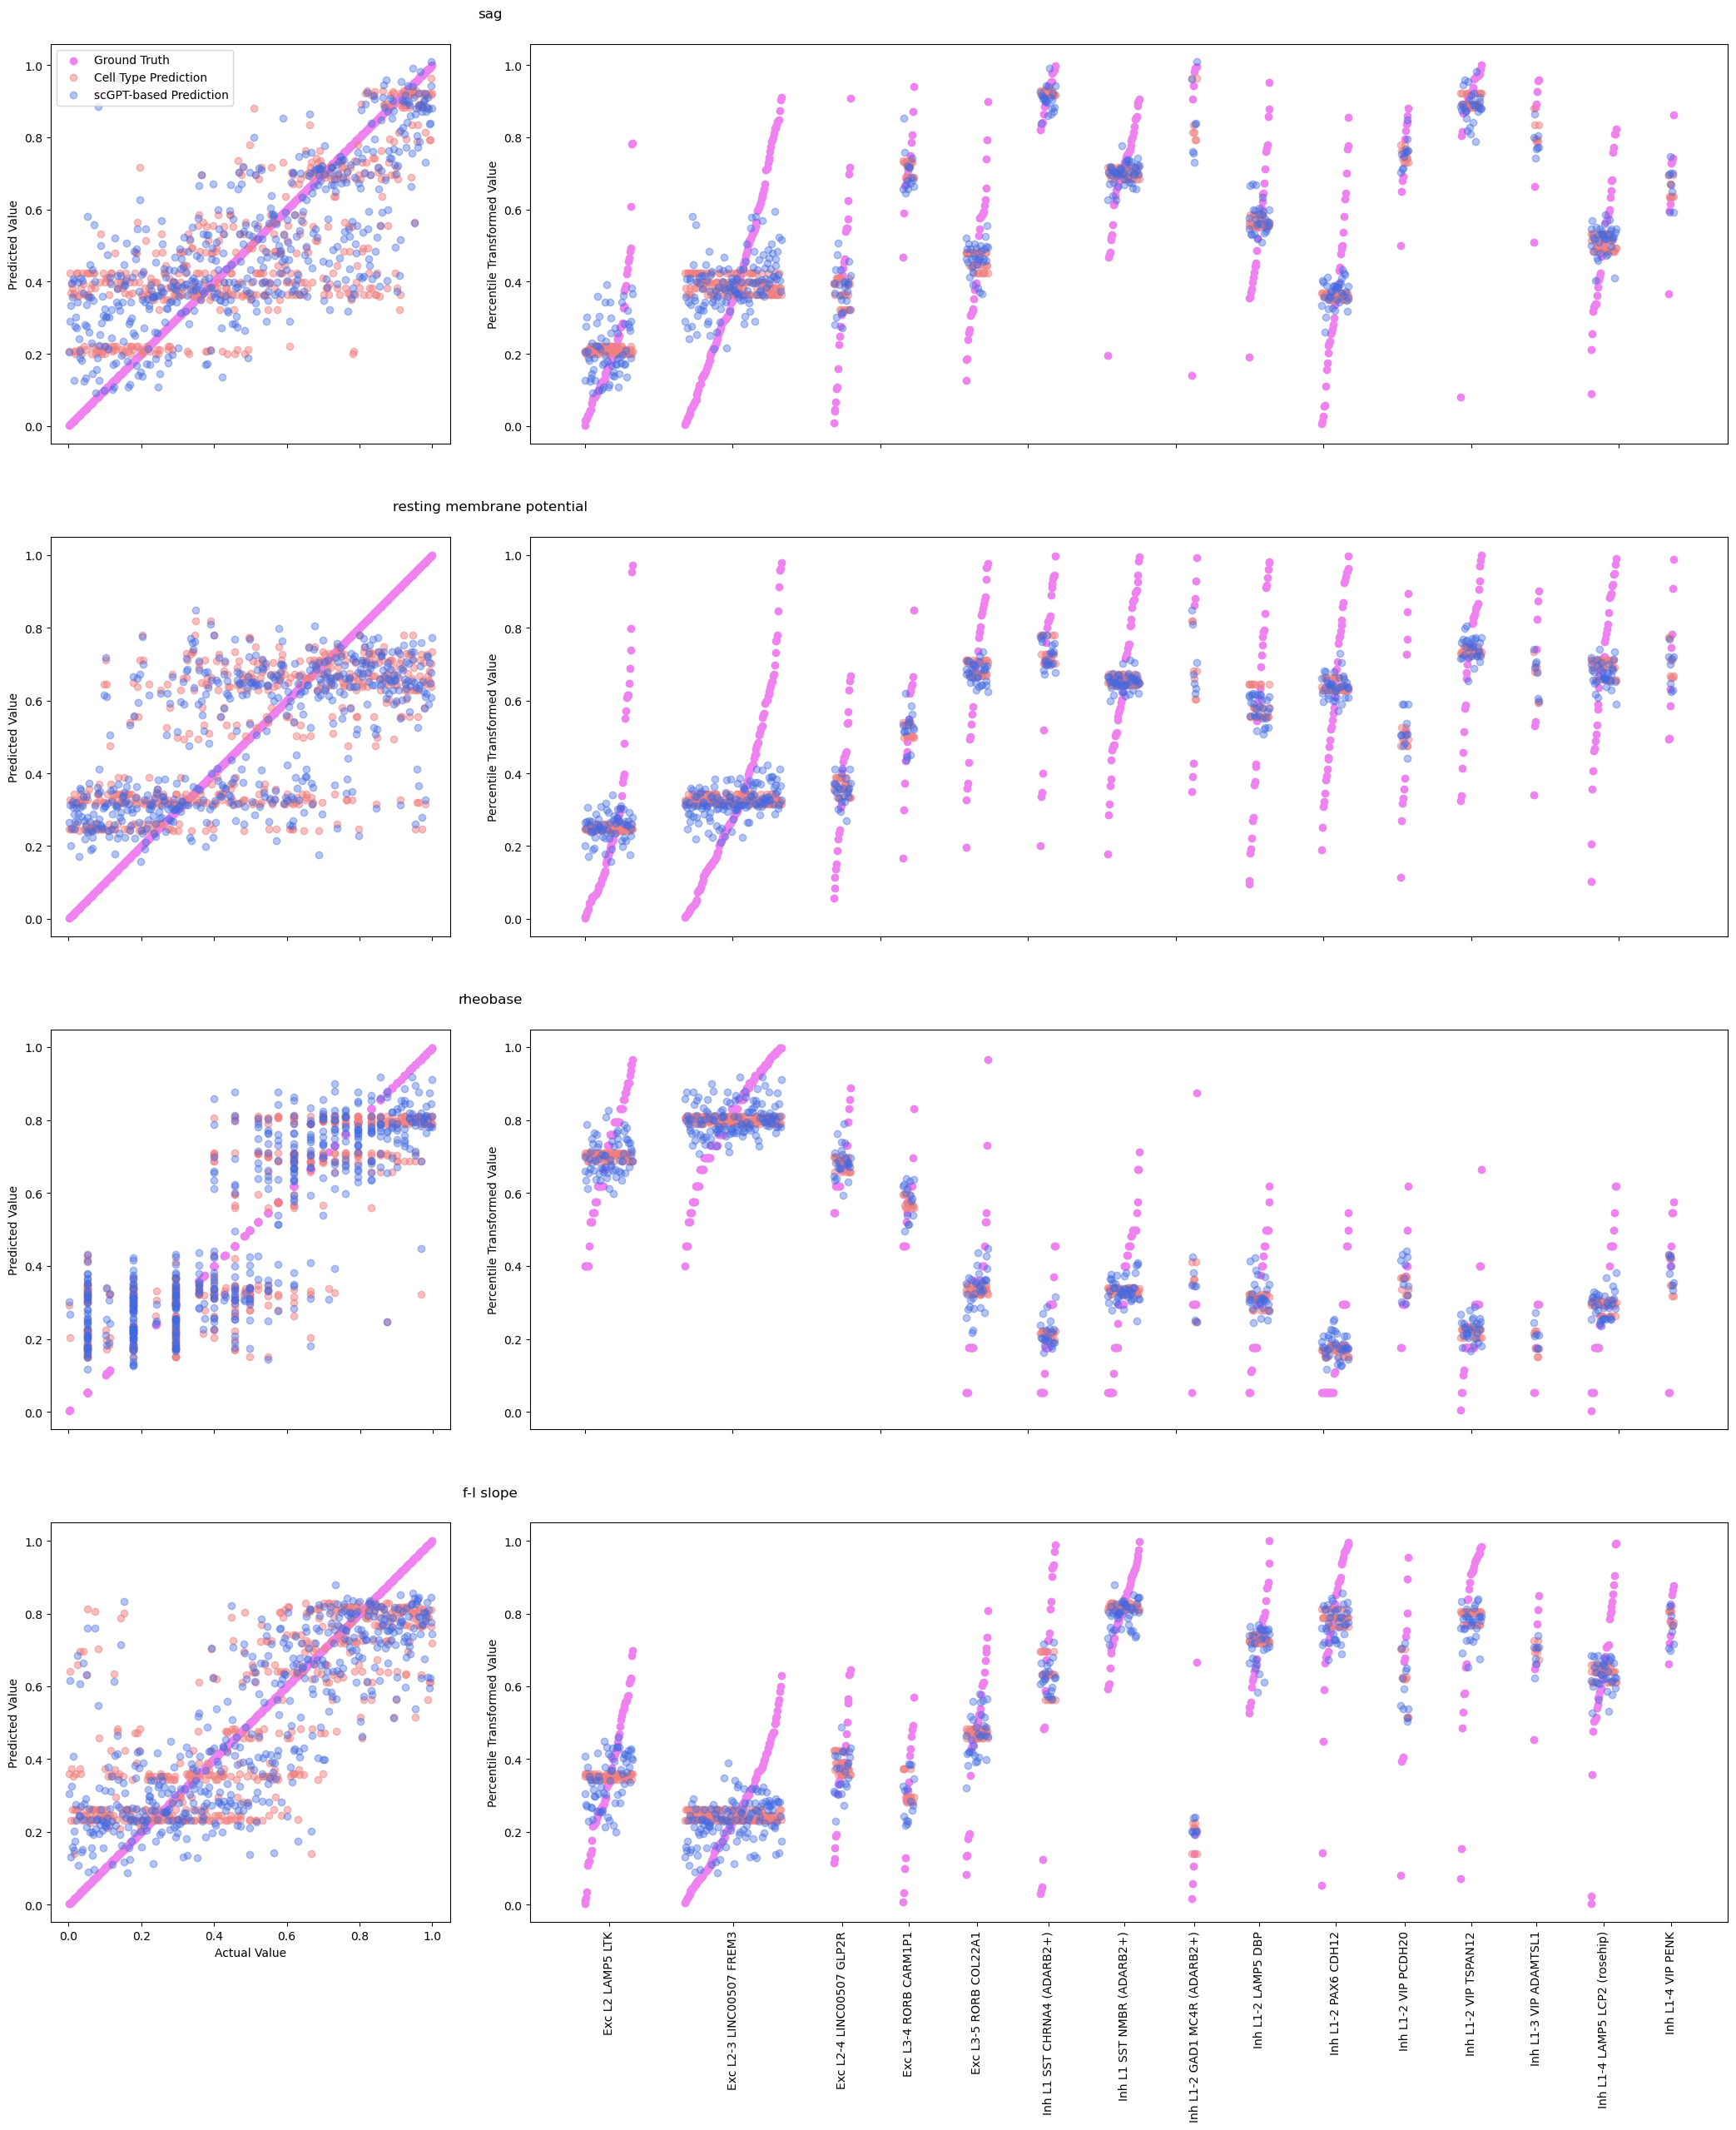

In [3]:
n_features_to_plot = 4

fig = plt.figure(figsize=(26, 24))
subfigs = fig.subfigures(nrows=4, ncols=1, hspace=-0.05)

all_cell_types = list(cell_embeddings_adata.obs["CellType"])

for i, subfig in enumerate(subfigs):
    feature_name = ephys_feature_names[i]

    axes = subfig.subplots(nrows=1, ncols=2, gridspec_kw={"width_ratios": [1, 3], "wspace": 0.1})
    ax_left, ax_right = axes
    
    bbox_left = ax_left.get_position()
    bbox_right = ax_right.get_position()
    mid_x = (bbox_left.x1 + bbox_right.x0) / 2
    subfig.suptitle(feature_name, x=mid_x, y=0.95)

    scgpt_preds = deepcopy(results["scgpt"]["predictions"][:, i])
    baseline_preds = deepcopy(results["cell type mean"]["predictions"][:, i])
    truth = deepcopy(ephys_truth[:, i])

    # LEFT PANEL
    ax_left.scatter(truth, truth, color="violet", label="Ground Truth" if i == 0 else "", alpha=1)
    ax_left.scatter(truth, baseline_preds, color="lightcoral", label="Cell Type Prediction" if i == 0 else "", alpha=0.5)
    ax_left.scatter(truth, scgpt_preds, color="royalblue", label="scGPT-based Prediction" if i == 0 else "", alpha=0.4)
    ax_left.set_ylabel("Predicted Value")

    if i == n_features_to_plot - 1:
        ax_left.set_xlabel("Actual Value")
    else:
        ax_left.tick_params(axis='x', which='both', labelbottom=False)

    # RIGHT PANEL
    sorted_cell_indices = deepcopy(shuffled_cell_indices)

    zipped = zip(scgpt_preds, baseline_preds, truth, sorted_cell_indices)
    sorted_zipped = sorted(zipped, key=lambda x: x[2])
    (sorted_scgpt_preds, sorted_baseline_preds, sorted_truth, sorted_cell_indices) = zip(*sorted_zipped)

    ordered_cell_types = [all_cell_types[idx] for idx in sorted_cell_indices]
    unique_cell_types = sorted(set(ordered_cell_types))

    grouped_data = {cell_type: [] for cell_type in unique_cell_types}
    for j, cell_type in enumerate(ordered_cell_types):
        grouped_data[cell_type].append((sorted_scgpt_preds[j], sorted_baseline_preds[j], sorted_truth[j]))

    current_position = 0
    cell_type_positions = []

    spacing = 70

    for cell_type in unique_cell_types:

        data = grouped_data[cell_type]
        n = len(data)

        x_pos = np.arange(current_position, current_position + n)

        cell_type_positions.append(current_position + n / 2)

        scgpt_vals = [d[0] for d in data]
        baseline_vals = [d[1] for d in data]
        truth_vals = [d[2] for d in data]

        ax_right.scatter(x_pos, truth_vals, color="violet", label="Ground Truth" if i == 0 and current_position == 0 else "", alpha=1)
        ax_right.scatter(x_pos, baseline_vals, color="lightcoral", label="Cell Type Prediction" if i == 0 and current_position == 0 else "", alpha=0.5)
        ax_right.scatter(x_pos, scgpt_vals, color="royalblue", label="scGPT-based Prediction" if i == 0 and current_position == 0 else "", alpha=0.4)

        current_position += n + spacing

    ax_right.set_ylabel("Percentile Transformed Value")

    if i == n_features_to_plot - 1:
        ax_right.set_xticks(cell_type_positions)
        ax_right.set_xticklabels(unique_cell_types, rotation=90)
    else:
        ax_right.tick_params(axis='x', which='both', labelbottom=False)

subfigs[0].axes[0].legend(loc="upper left")
plt.show()
fig.savefig('Figures/wtypesscatter1.pdf', bbox_inches='tight')

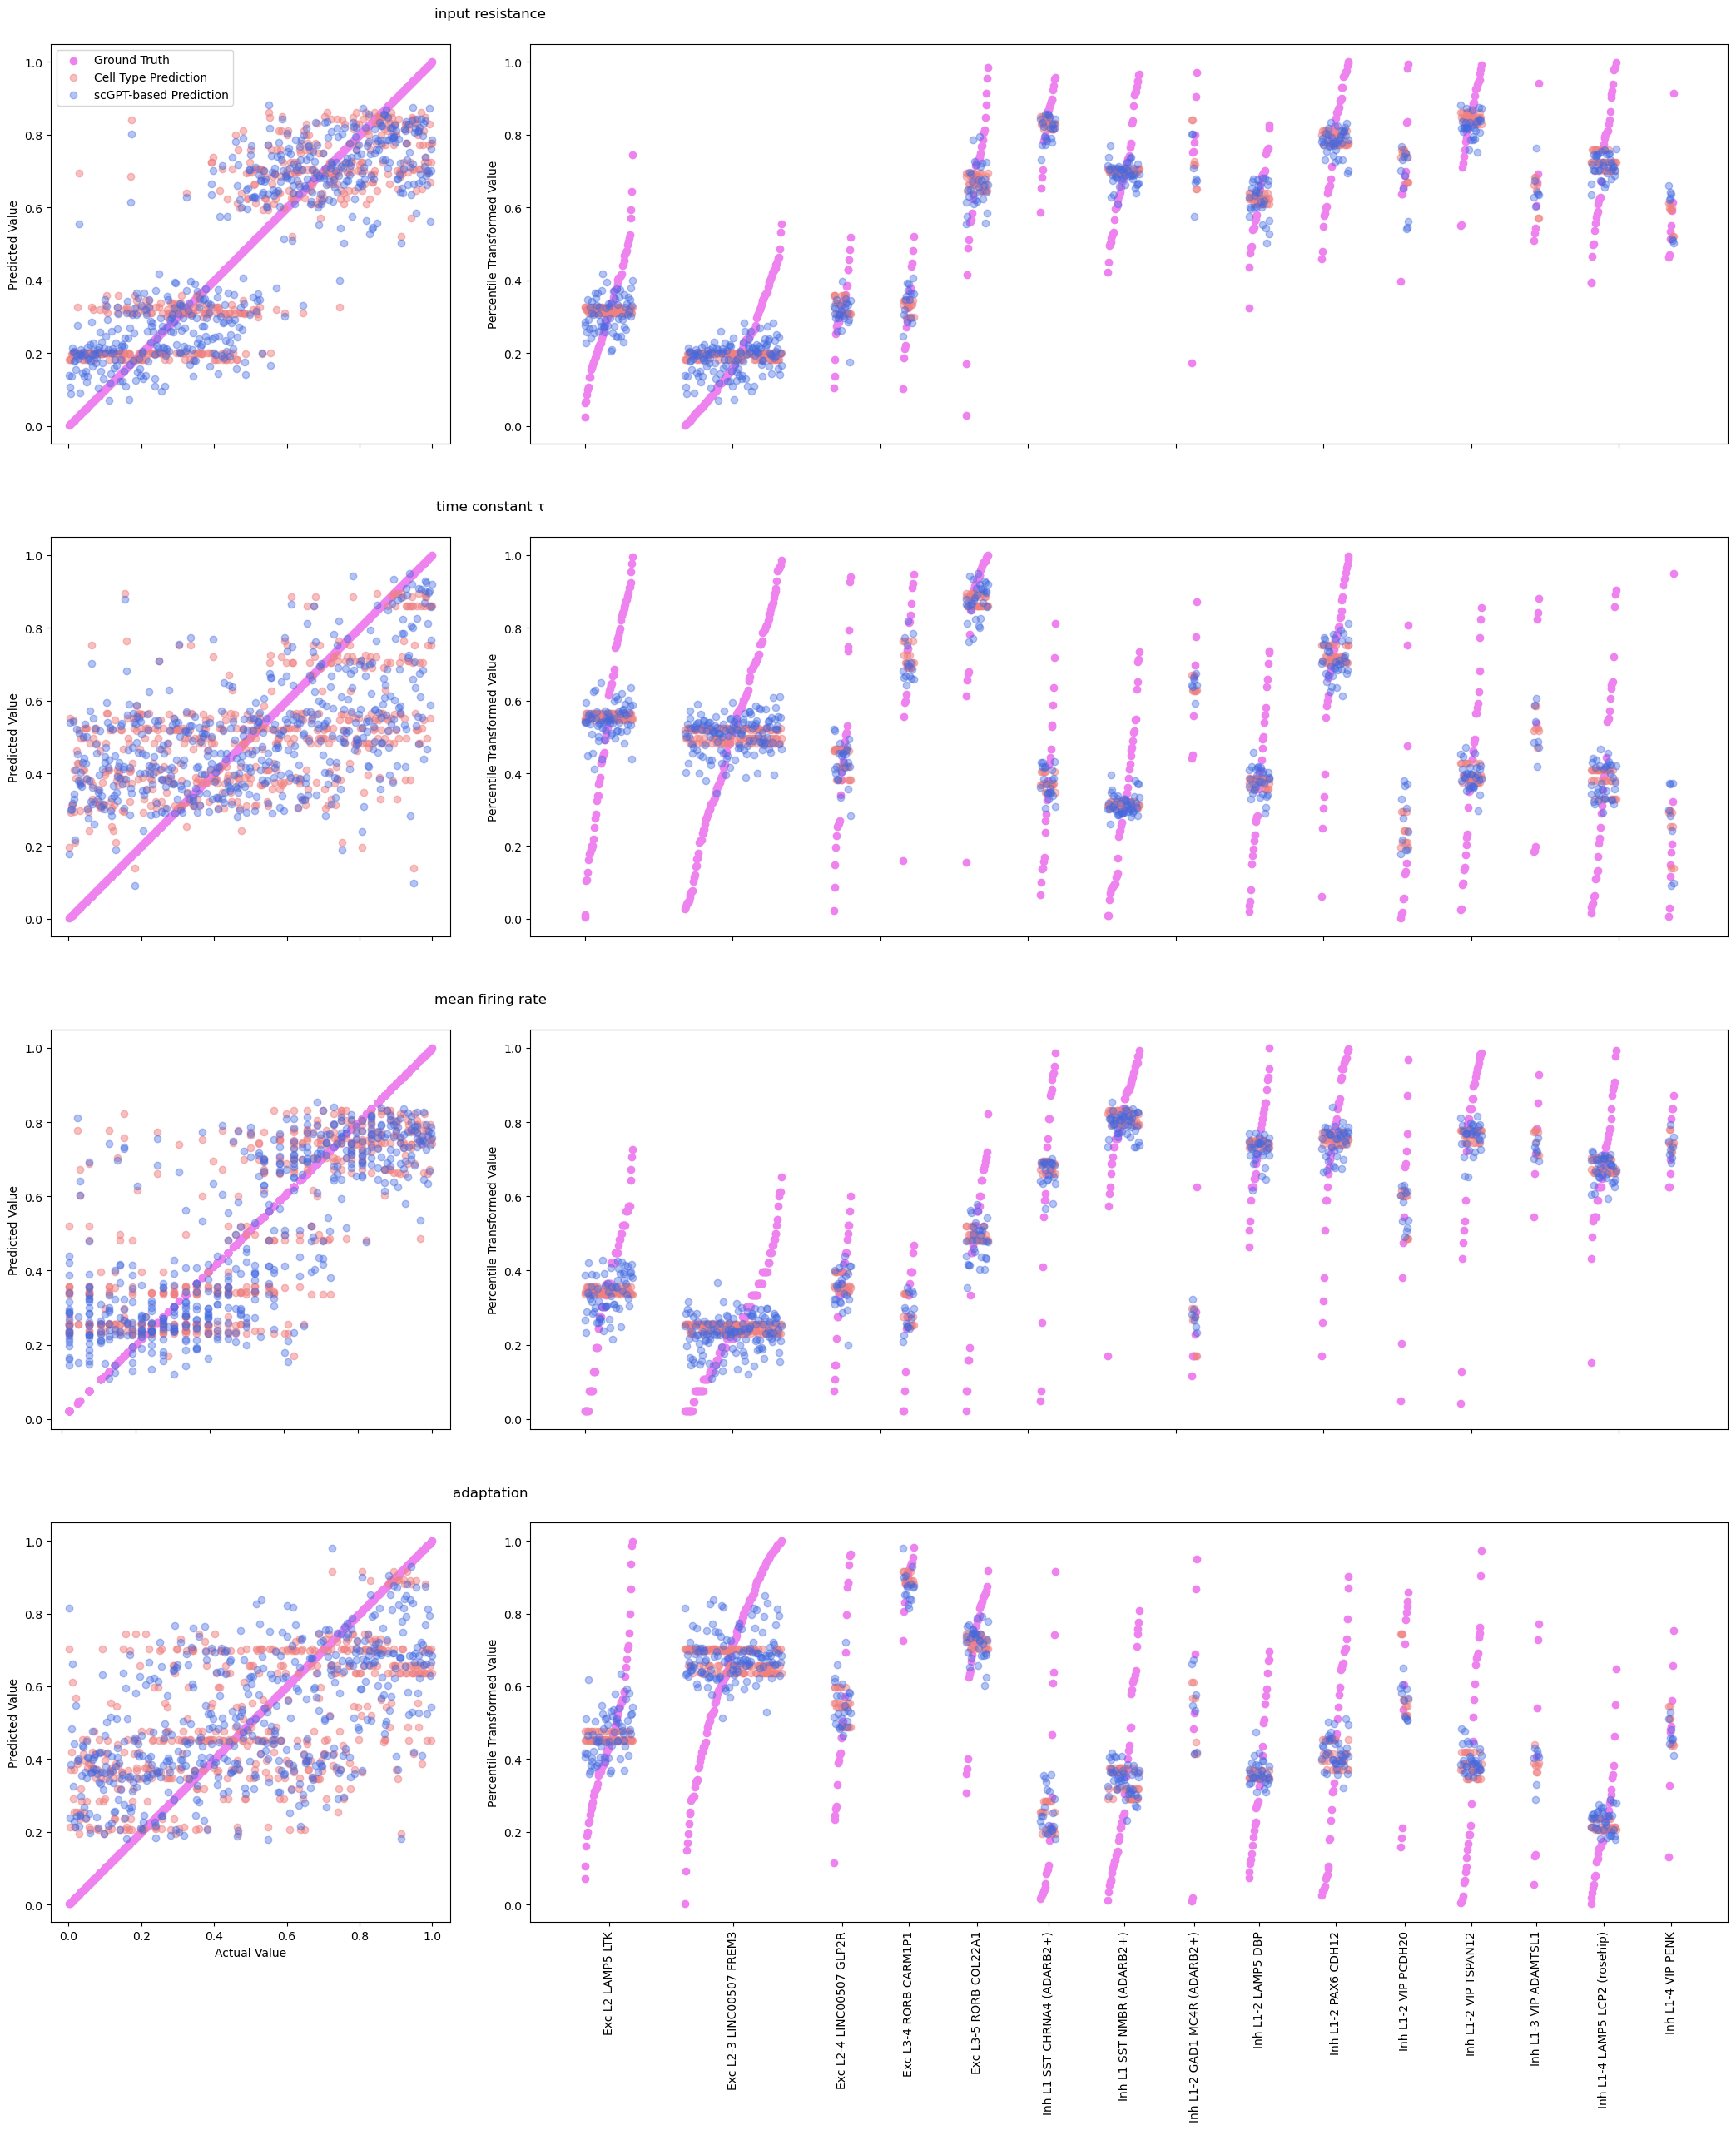

In [4]:
fig = plt.figure(figsize=(26, 24))
subfigs = fig.subfigures(nrows=n_features_to_plot, ncols=1, hspace=-0.05)

all_cell_types = list(cell_embeddings_adata.obs["CellType"])

for i, subfig in enumerate(subfigs):
    i = i + n_features_to_plot
    feature_name = ephys_feature_names[i]

    axes = subfig.subplots(nrows=1, ncols=2, gridspec_kw={"width_ratios": [1, 3], "wspace": 0.1})
    ax_left, ax_right = axes
    
    bbox_left = ax_left.get_position()
    bbox_right = ax_right.get_position()
    mid_x = (bbox_left.x1 + bbox_right.x0) / 2
    subfig.suptitle(feature_name, x=mid_x, y=0.95)

    scgpt_preds = deepcopy(results["scgpt"]["predictions"][:, i])
    baseline_preds = deepcopy(results["cell type mean"]["predictions"][:, i])
    truth = deepcopy(ephys_truth[:, i])

    # LEFT PANEL
    ax_left.scatter(truth, truth, color="violet", label="Ground Truth" if i == n_features_to_plot else "", alpha=1)
    ax_left.scatter(truth, baseline_preds, color="lightcoral", label="Cell Type Prediction" if i == n_features_to_plot else "", alpha=0.5)
    ax_left.scatter(truth, scgpt_preds, color="royalblue", label="scGPT-based Prediction" if i == n_features_to_plot else "", alpha=0.4)
    ax_left.set_ylabel("Predicted Value")

    if i == len(ephys_feature_names) - 1:
        ax_left.set_xlabel("Actual Value")
    else:
        ax_left.tick_params(axis='x', which='both', labelbottom=False)

    # RIGHT PANEL
    sorted_cell_indices = deepcopy(shuffled_cell_indices)

    zipped = zip(scgpt_preds, baseline_preds, truth, sorted_cell_indices)
    sorted_zipped = sorted(zipped, key=lambda x: x[2])
    (sorted_scgpt_preds, sorted_baseline_preds, sorted_truth, sorted_cell_indices) = zip(*sorted_zipped)

    ordered_cell_types = [all_cell_types[idx] for idx in sorted_cell_indices]
    unique_cell_types = sorted(set(ordered_cell_types))

    grouped_data = {cell_type: [] for cell_type in unique_cell_types}
    for j, cell_type in enumerate(ordered_cell_types):
        grouped_data[cell_type].append((sorted_scgpt_preds[j], sorted_baseline_preds[j], sorted_truth[j]))

    current_position = 0
    cell_type_positions = []

    spacing = 70

    for cell_type in unique_cell_types:

        data = grouped_data[cell_type]
        n = len(data)

        x_pos = np.arange(current_position, current_position + n)

        cell_type_positions.append(current_position + n / 2)

        scgpt_vals = [d[0] for d in data]
        baseline_vals = [d[1] for d in data]
        truth_vals = [d[2] for d in data]

        ax_right.scatter(x_pos, truth_vals, color="violet", label="Ground Truth" if i == n_features_to_plot and current_position == 0 else "", alpha=1)
        ax_right.scatter(x_pos, baseline_vals, color="lightcoral", label="Cell Type Prediction" if i == n_features_to_plot and current_position == 0 else "", alpha=0.5)
        ax_right.scatter(x_pos, scgpt_vals, color="royalblue", label="scGPT-based Prediction" if i == n_features_to_plot and current_position == 0 else "", alpha=0.4)

        current_position += n + spacing

    ax_right.set_ylabel("Percentile Transformed Value")

    if i == len(ephys_feature_names) - 1:
        ax_right.set_xticks(cell_type_positions)
        ax_right.set_xticklabels(unique_cell_types, rotation=90)
    else:
        ax_right.tick_params(axis='x', which='both', labelbottom=False)

subfigs[0].axes[0].legend(loc="upper left")
plt.show()
fig.savefig('Figures/wtypesscatter2.pdf', bbox_inches='tight')

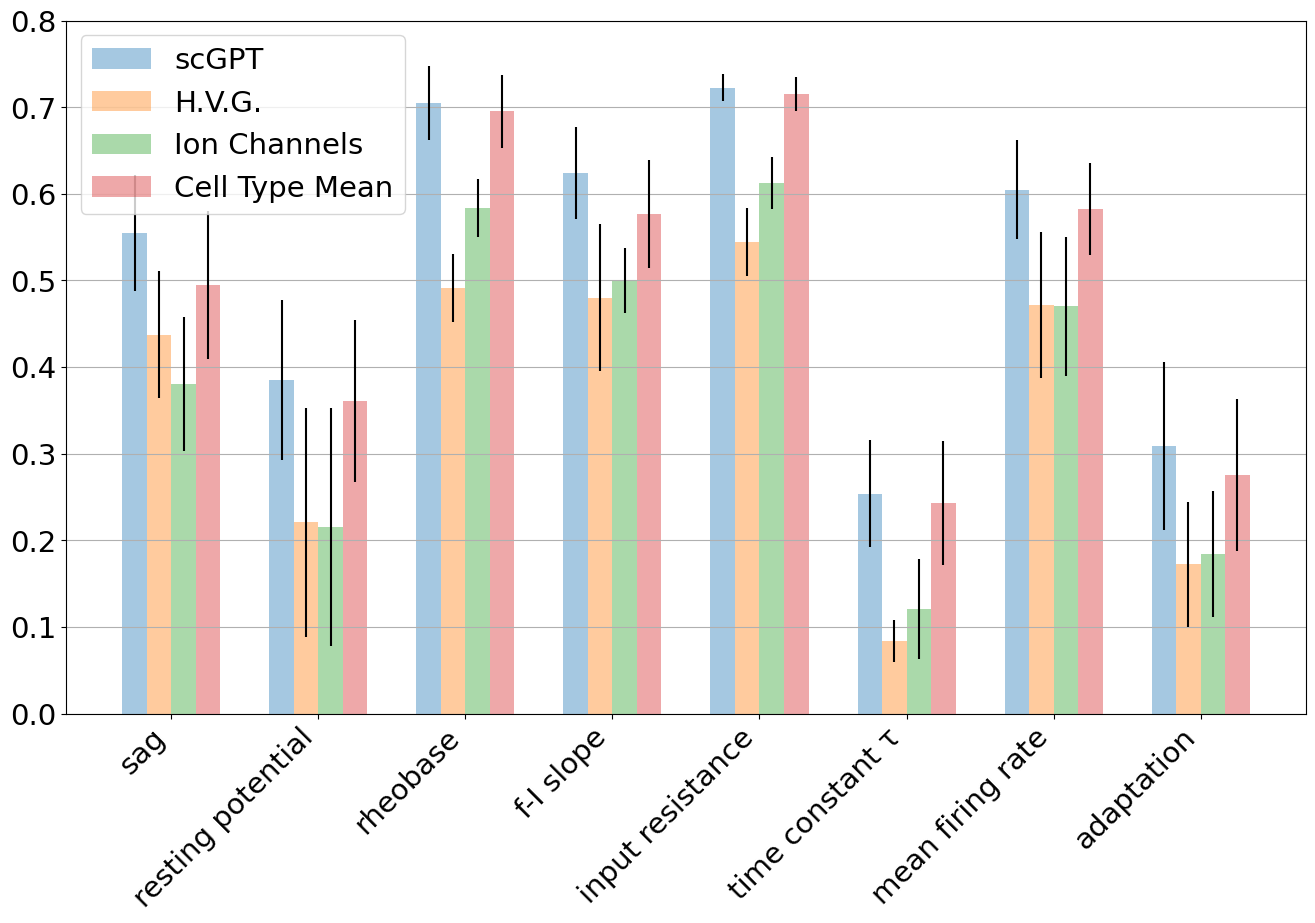

In [5]:
labels = ["scGPT", "H.V.G.", "Ion Channels", "Cell Type Mean"]
data = []
errors = []

for model in models:
    # r2_scores is (number of outer folds)x(number of epochs)x(number of ephys features)
    data.append(np.mean(results[model]["r2_scores"][:,-1,:], axis=0))
    errors.append(np.std(results[model]["r2_scores"][:,-1,:], axis=0))
    
data.append(np.mean(results["cell type mean"]["r2_scores"], axis=0))
errors.append(np.std(results["cell type mean"]["r2_scores"], axis=0))

x = np.arange(8)*1.2  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

plt.rcParams.update({'font.size': 21})
fig, ax = plt.subplots(figsize=(16, 9))
for group_label, group_data, group_error in zip(labels, data, errors):
    offset = width * multiplier
    rects = ax.bar(x + offset, group_data, width, label=group_label, alpha=0.4, yerr=group_error)
    multiplier += 1

feature_names = [col for col in combined_ephys_df.columns if col != "SpecimenID"]
feature_names[1] = "resting potential"
ax.set_xticks(x + width*1.5, feature_names, rotation=45, ha="right")
plt.ylim(0, 0.8)
# ax.set_title("Final Epoch Test R² Across Electrophysiological Features")
# ax.set_xlabel("Electrophysiological Feature")
# ax.set_ylabel("R²")
ax.legend()
ax.yaxis.grid(True)

plt.savefig("Figures/barchart.svg", format="svg", bbox_inches="tight")
plt.show()